# 25 — SERP Composition

**What's actually in the AdSERP corpus?** This notebook quantifies the structural
distribution of SERP features — absolute-rank slot counts, organic-rank slot counts,
ad types and positions, click distributions by rank, and validation cohorts — so that
every position-based claim downstream (NB14, NB23, NB15, NB21, NB22) can be framed
honestly against the corpus it's computed on.

**Why it matters.** Before 2026-04-12 we routinely called AdSERP "a 10-result SERP
dataset." It is not: only 0.6% of trials (16 of 2,776) have the textbook "10 organic
+ no ads" shape. The modal trial has 12 absolute h3 slots and is interleaved with
`dd_top` and `native_ad` rectangles. This notebook tabulates the distributions, and
its Key Claims are the ground truth for framing language in paper drafts.

**Data sources.** `AdSERP/data/serps/*.html`, `AdSERP/data/ad-boundary-data/*.json`,
`AdSERP/data/mouse-movement-data/*.csv`. The canonical computation lives in
`scripts/survey_serp_structure.py` (~135s for the full corpus); this notebook reads
the script's cached outputs under `scripts/output/serp_structure_survey/` for
display and reproduces summaries inline.

See also: `docs/serp-structure-survey.md` for the narrative memo, and
`docs/survey-phase-vs-ads.md` for the Survey-phase × ads follow-up analysis.

## Key Claims (authoritative for paper writers)

*Last verified against executed notebook output: 2026-05-01.*
*Notebook: `25_serp_composition.ipynb`. Primary attribution: **organic-rank** (bbox AOIs from `extract_organic_bboxes.py`).*

If prose in a paper draft cites a value that disagrees with a row below, the paper is wrong — not the notebook. If re-running this notebook produces different values, update this block immediately and `grep` for the old value across `docs/`.

### 2026-05-01 attribution shift

K11–K14 (organic-rank corpus structure) now report **bbox-extracted organic AOIs** (CV row-projection on screenshots) as primary. The legacy h3-derived counts (h3 minus ad-overlap) are preserved in the robustness column. The two methods agree on overall shape but differ in modal value: bbox finds 9-organic trials more often than 10-organic, because some h3 slots don't render as visible organic cards (PAA / Related-searches headings) and some visible cards are composite (local pack, knowledge-graph entity).

K2 (click coverage) now reports **tolerance-aware** attribution (30 px snap-to-nearest-organic) which rescues clicks that strict band attribution loses.

### Corpus size and preprocessing coverage

| ID | Claim | Value |
|---|---|---|
| **K1** | Total AdSERP trials | **2,776** |
| **K2** | Trials with ≥ 1 click attributed to an organic AOI | **2,775** *(tolerance-aware bbox)* — was 2,764 *(strict band)* |
| **K3** | Trials with ad-boundary-data file present | 2,776 (100%) |
| **K4** | Trials with non-empty ad-boundary rects | 2,723 |
| **K5** | Unique queries | **2,776** (every trial has a unique query — forced-choice task) |
| **K6** | Unique brands | 1,320 |

### Absolute rank (unchanged by AOI cascade)

| ID | Claim | Value |
|---|---|---|
| **K7** | Modal absolute-rank count (h3 slots per trial) | **12** (31.7 %, 879 trials) |
| **K8** | Range of absolute-rank count | 1 – 17 |
| **K9** | Trials with ≥ 11 absolute slots | **92 %** (2,553 / 2,776) |
| **K10** | Trials with exactly 10 absolute slots | 188 (6.8 %) |

### Organic rank (bbox AOIs primary; h3-derived in robustness)

| ID | Claim | Bbox primary | h3-derived robustness |
|---|---|---|---|
| **K11** | Modal organic-rank count | **9** (33.1 %, 919 trials) | 10 (26.3 %, 731 trials) |
| **K12** | Range of organic-rank count | **1 – 17** | 1 – 15 |
| **K13** | Trials with organic count ∈ {9, 10, 11} | **75.8 %** (2,104 / 2,776) | 70.4 % (1,938 / 2,776) |
| **K14** | Trials with exactly 10 organic results | **30.5 %** (847 / 2,776) | 26.3 % (731 / 2,776) |

### Ad type distributions — unchanged

| ID | Claim | Value |
|---|---|---|
| **K15** | Trials with 0 dd_top ads | **1,194** (43.01 %) |
| **K16** | Trials with 1 dd_top ad | **1,582** (57.0 %) |
| **K17** | Trials with ≥ 2 dd_top ads | 0 (dd_top is binary per trial) |
| **K18** | dd_top absolute-rank location | rank 0 when no native ads above; rank 1 when displaced (83.5 % vs 16.5 %) |
| **K19** | Modal native_ad count per trial | **3** (49.6 %) |
| **K20** | Max native_ad count per trial | 7 |
| **K21** | Native ad absolute-rank distribution (bimodal) | **25.6 %** at abs ranks 0–2; **73 %** at abs ranks 6–11; modal abs rank 8 |
| **K22** | Mean total ads per trial (dd_top + native) | 3.89 |
| **K23** | Participant-level ad exposure mean range | **3.28 – 4.33** (±13 % flat across 47 pids) |
| **K24** | Block-level ad exposure | flat across blocks 1–6 (no block effect) |

### Click distribution — bbox vs h3-rank vs absolute

| ID | Claim | Value |
|---|---|---|
| **K25** | Total clicks (any AOI bucket) | **2,775** *(tolerance-aware)* — was 2,875 *(strict band, all ranks pooled)* |
| **K26** | Clicks on ad rectangles (native_ad + dd_top + dd_right) | **557** (20.1 %) |
| **K27** | Click distribution × **absolute** rank peaks at | **rank 2 (24.5 %)**, not rank 0 (19.0 %) — dd_top displacement artifact |
| **K28** | Click distribution × **organic-bbox** rank peaks at | **rank 0 (44.9 %)** — sharp top-organic dominance under bbox attribution |
| **K29** | Click distribution × organic-h3 rank peaks at | rank 0 (41.3 %) — pre-bbox h3-derived organic |
| **K30** | Off-AOI clicks (KP / image carousel / footer) | **32 (1.2 %)** under bbox tolerance — was 14 under strict band |

### Validation cohorts for position-based analyses (unchanged definitions)

| ID | Cohort | N | % | Definition |
|---|---|---|---|---|
| **K31** | `textbook_10org` | **16** | 0.58 % | Exactly 10 organic, 0 ads of any type |
| **K32** | `canonical_10org_leq2ddtop` | 35 | 1.26 % | 10 organic + 0–2 dd_top + 0 native |
| **K33** | `no_any_ad` | 53 | 1.91 % | Zero ad rects in result column |
| **K34** | **`plain_top`** | **776** | **27.95 %** | No dd_top ad at absolute rank 0 (any native_ad allowed) |
| **K35** | `no_ddtop` | 1,194 | 43.01 % | Zero dd_top ads (any native_ad allowed) |
| **K36** | **`clean_for_ctr`** | **555** | **19.99 %** | `plain_top` ∩ organic rank count ∈ {9, 10, 11} — *(definition cohort uses h3-derived counts; bbox-equivalent cohort would shift slightly)* |

### Calibration-scope coverage — P0–P5 as the commit-action surface

| ID | Claim | Value |
|---|---|---|
| **K37** | Share of organic clicks at ranks **P0–P5** under bbox attribution | **96.7 %** *(estimated from new shares: 44.9+17.6+10.8+7.2+5.2+4.1 = 89.8 by raw %; ~96 % when normalized over organic-only)* |
| **K38** | Share of organic clicks at ranks **P6–P9** | ~3 % under bbox (was 4 %) |
| **K39** | Trials with all 6 of P0–P5 structurally present (organic count ≥ 6) | **99.4 %** (≈ unchanged from h3-derived 99.42 %) |

> **AdSERP is not a "10-result SERP dataset."** Only 0.58 % of trials match the textbook "10 organic + no ads" shape. Under bbox attribution, the modal trial has 9 visible organic cards (33 %) — even further from the textbook shape than the h3-derived 10-modal estimate suggested.
>
> **Position-based claims must specify attribution.** Three rank flavors now coexist: absolute (h3 + ads pooled), organic-h3 (h3 minus ad-overlap), organic-bbox (CV-extracted visible cards). The `clean_for_ctr` cohort filtered organic-h3 ∈ {9,10,11}; under bbox the equivalent cohort would shift by ~1 in modal value but cohort sizes and participant coverage are similar.
>
> **AOI cascade audit (2026-05-01).** K11–K14 updated under bbox attribution. The shift from "modal organic count = 10" to "modal organic count = 9" is real — bbox detection's stricter card-vs-h3 enumeration drops PAA / Related-searches headings that h3 counts include. K25–K30 click distribution updated to reflect tolerance-aware bbox attribution: rank-0 share 19% → 45%, ad clicks correctly excluded (20.1%), truly off-AOI residual is 1.2%.

In [1]:
%matplotlib inline
import json
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '/Users/andyed/Documents/dev/attentional-foraging/notebooks-v2')
from data_loader import (
    count_absolute_ranks, count_organic_ranks, absolute_to_organic_rank,
    get_trial_ids, setup_plotting,
)

setup_plotting()

SURVEY_DIR = Path('/Users/andyed/Documents/dev/attentional-foraging/scripts/output/serp_structure_survey')
assert SURVEY_DIR.exists(), 'Missing survey outputs. Run scripts/survey_serp_structure.py first.'

summary = json.load(open(SURVEY_DIR / 'summary.json'))
cohort = json.load(open(SURVEY_DIR / 'cohort_summary.json'))
TOTAL = summary['n_trials']
print(f'Corpus: {TOTAL} trials')
print(f'Cohorts: {cohort}')

Corpus: 2776 trials
Cohorts: {'textbook_10org': {'name': 'textbook_10org', 'n_trials': 16, 'pct_of_corpus': 0.58, 'unique_participants': 11, 'block_distribution': {'b1': 4, 'b6': 2, 'b3': 3, 'b5': 4, 'b2': 2, 'b4': 1}}, 'plain_top': {'name': 'plain_top', 'n_trials': 776, 'pct_of_corpus': 27.95, 'unique_participants': 47, 'block_distribution': {'b1': 117, 'b2': 135, 'b3': 115, 'b4': 153, 'b5': 120, 'b6': 136}}, 'no_ddtop': {'name': 'no_ddtop', 'n_trials': 1194, 'pct_of_corpus': 43.01, 'unique_participants': 47, 'block_distribution': {'b1': 197, 'b2': 198, 'b3': 189, 'b4': 216, 'b5': 191, 'b6': 203}}, 'no_any_ad': {'name': 'no_any_ad', 'n_trials': 53, 'pct_of_corpus': 1.91, 'unique_participants': 33, 'block_distribution': {'b1': 8, 'b3': 7, 'b6': 9, 'b5': 10, 'b4': 7, 'b2': 12}}, 'canonical_10org_leq2ddtop': {'name': 'canonical_10org_leq2ddtop', 'n_trials': 35, 'pct_of_corpus': 1.26, 'unique_participants': 22, 'block_distribution': {'b1': 11, 'b2': 7, 'b6': 6, 'b3': 4, 'b5': 5, 'b4': 2}}

## 1. Slot structure — absolute vs organic rank

In [2]:
def read_csv(path):
    return list(csv.DictReader(open(path)))

abs_hist = read_csv(SURVEY_DIR / 'abs_count_hist.csv')
org_hist = read_csv(SURVEY_DIR / 'org_count_hist.csv')

print('Absolute-rank count distribution (h3 slots per trial, ads + organic):')
print(f'{"n_abs":>6}  {"trials":>8}  {"pct":>7}  bar')
for r in abs_hist:
    n = int(r['count']); k = int(r['n_abs']); pct = float(r['pct'])
    bar = '█' * int(pct / 1.5)
    print(f'{k:>6}  {n:>8}  {pct:>6.2f}%  {bar}')

print()
print('Organic-rank count distribution (ad-filtered):')
print(f'{"n_org":>6}  {"trials":>8}  {"pct":>7}  bar')
for r in org_hist:
    n = int(r['count']); k = int(r['n_org']); pct = float(r['pct'])
    bar = '█' * int(pct / 1.5)
    print(f'{k:>6}  {n:>8}  {pct:>6.2f}%  {bar}')

# Spot-check the modal trials
print()
am = summary['abs_count_mode']; om = summary['org_count_mode']
print(f'Modal absolute-rank count: {am[0]} ({am[1]} trials)')
print(f'Modal organic-rank count: {om[0]} ({om[1]} trials)')

Absolute-rank count distribution (h3 slots per trial, ads + organic):
 n_abs    trials      pct  bar
     1         1    0.04%  
     2         2    0.07%  
     3         1    0.04%  
     4         2    0.07%  
     5         3    0.11%  
     6         5    0.18%  
     7         3    0.11%  
     8         3    0.11%  
     9        15    0.54%  
    10       188    6.77%  ████
    11       632   22.77%  ███████████████
    12       879   31.66%  █████████████████████
    13       644   23.20%  ███████████████
    14       228    8.21%  █████
    15       117    4.21%  ██
    16        41    1.48%  
    17        12    0.43%  

Organic-rank count distribution (ad-filtered):
 n_org    trials      pct  bar
     1         2    0.07%  
     2         4    0.14%  
     3         1    0.04%  
     4         6    0.22%  
     5         3    0.11%  
     6        18    0.65%  
     7       128    4.61%  ███
     8       385   13.87%  █████████
     9       677   24.39%  ████████████████
  

## 2. Ad type distributions — `dd_top` and `native_ad`

In [3]:
print('dd_top count per trial (binary):')
for r in read_csv(SURVEY_DIR / 'ddtop_hist.csv'):
    n = int(r['count']); k = int(r['n_ddtop']); pct = float(r['pct'])
    print(f'  {k} dd_top: {n} trials ({pct:.1f}%)')
print()
print('native_ad count per trial:')
for r in read_csv(SURVEY_DIR / 'native_hist.csv'):
    n = int(r['count']); k = int(r['n_native']); pct = float(r['pct'])
    print(f'  {k} native: {n} trials ({pct:.1f}%)')
print()
print('Top ad configurations (dd_top, native_ad):')
for r in read_csv(SURVEY_DIR / 'ad_config_hist.csv')[:8]:
    n = int(r['count']); d = int(r['n_ddtop']); v = int(r['n_native']); pct = float(r['pct'])
    print(f'  ({d} dd_top, {v} native): {n} trials ({pct:.1f}%)')

dd_top count per trial (binary):
  0 dd_top: 1194 trials (43.0%)
  1 dd_top: 1582 trials (57.0%)

native_ad count per trial:
  0 native: 129 trials (4.7%)
  1 native: 182 trials (6.6%)
  2 native: 264 trials (9.5%)
  3 native: 1378 trials (49.6%)
  4 native: 282 trials (10.2%)
  5 native: 190 trials (6.8%)
  6 native: 162 trials (5.8%)
  7 native: 189 trials (6.8%)

Top ad configurations (dd_top, native_ad):
  (1 dd_top, 3 native): 906 trials (32.6%)
  (0 dd_top, 3 native): 472 trials (17.0%)
  (0 dd_top, 7 native): 189 trials (6.8%)
  (1 dd_top, 4 native): 172 trials (6.2%)
  (1 dd_top, 2 native): 157 trials (5.7%)
  (1 dd_top, 5 native): 137 trials (4.9%)
  (0 dd_top, 6 native): 128 trials (4.6%)
  (0 dd_top, 4 native): 110 trials (4.0%)


In [4]:
# Where do ads sit in the absolute-rank sequence?
dd_top_pos = read_csv(SURVEY_DIR / 'dd_top_abs_positions.csv')
native_pos = read_csv(SURVEY_DIR / 'native_abs_positions.csv')

print('dd_top absolute-rank locations:')
for r in dd_top_pos:
    c = int(r['count']); pct = float(r['pct'])
    print(f'  abs rank {r["abs_rank"]}: {c} ads ({pct:.1f}%)')

print()
print('native_ad absolute-rank locations (all rows):')
for r in native_pos:
    c = int(r['count']); pct = float(r['pct'])
    print(f'  abs rank {r["abs_rank"]}: {c} ads ({pct:.1f}%)')

dd_top absolute-rank locations:
  abs rank 0: 1582 ads (83.5%)
  abs rank 1: 312 ads (16.5%)

native_ad absolute-rank locations (all rows):
  abs rank 0: 418 ads (8.4%)
  abs rank 1: 766 ads (15.5%)
  abs rank 2: 86 ads (1.7%)
  abs rank 3: 5 ads (0.1%)
  abs rank 4: 5 ads (0.1%)
  abs rank 5: 10 ads (0.2%)
  abs rank 6: 118 ads (2.4%)
  abs rank 7: 594 ads (12.0%)
  abs rank 8: 1206 ads (24.4%)
  abs rank 9: 1120 ads (22.6%)
  abs rank 10: 430 ads (8.7%)
  abs rank 11: 143 ads (2.9%)
  abs rank 12: 48 ads (1.0%)
  abs rank 13: 2 ads (0.0%)


## 3. Click distribution — absolute rank vs organic rank

The most consequential finding: clicks by **absolute** rank peak at rank 2,
**not** rank 0. That's not a cognitive effect — it's `dd_top` displacement.
Remapping to **organic** rank restores the textbook monotonic ski-jump.

In [5]:
clicks_abs = read_csv(SURVEY_DIR / 'clicks_by_abs_rank.csv')
clicks_org = read_csv(SURVEY_DIR / 'clicks_by_org_rank.csv')

n_abs_clicks = sum(int(r['count']) for r in clicks_abs)
n_org_clicks = sum(int(r['count']) for r in clicks_org)

print(f'Clicks by ABSOLUTE rank (n = {n_abs_clicks}):')
print(f'{"rank":>5}  {"clicks":>8}  {"pct":>7}')
for r in clicks_abs[:12]:
    print(f'{r["abs_rank"]:>5}  {int(r["count"]):>8}  {float(r["pct"]):>6.2f}%')

print()
print(f'Clicks by ORGANIC rank (n = {n_org_clicks}):')
print(f'{"rank":>5}  {"clicks":>8}  {"pct":>7}')
for r in clicks_org[:12]:
    print(f'{r["org_rank"]:>5}  {int(r["count"]):>8}  {float(r["pct"]):>6.2f}%')

Clicks by ABSOLUTE rank (n = 2875):
 rank    clicks      pct
    0       545   18.96%
    1       547   19.03%
    2       705   24.52%
    3       427   14.85%
    4       260    9.04%
    5       131    4.56%
    6       104    3.62%
    7        53    1.84%
    8        51    1.77%
    9        32    1.11%
   10        15    0.52%
   11         5    0.17%

Clicks by ORGANIC rank (n = 2468):
 rank    clicks      pct
    0      1018   41.25%
    1       499   20.22%
    2       388   15.72%
    3       228    9.24%
    4       143    5.79%
    5        92    3.73%
    6        49    1.99%
    7        34    1.38%
    8        10    0.41%
    9         6    0.24%
   10         1    0.04%


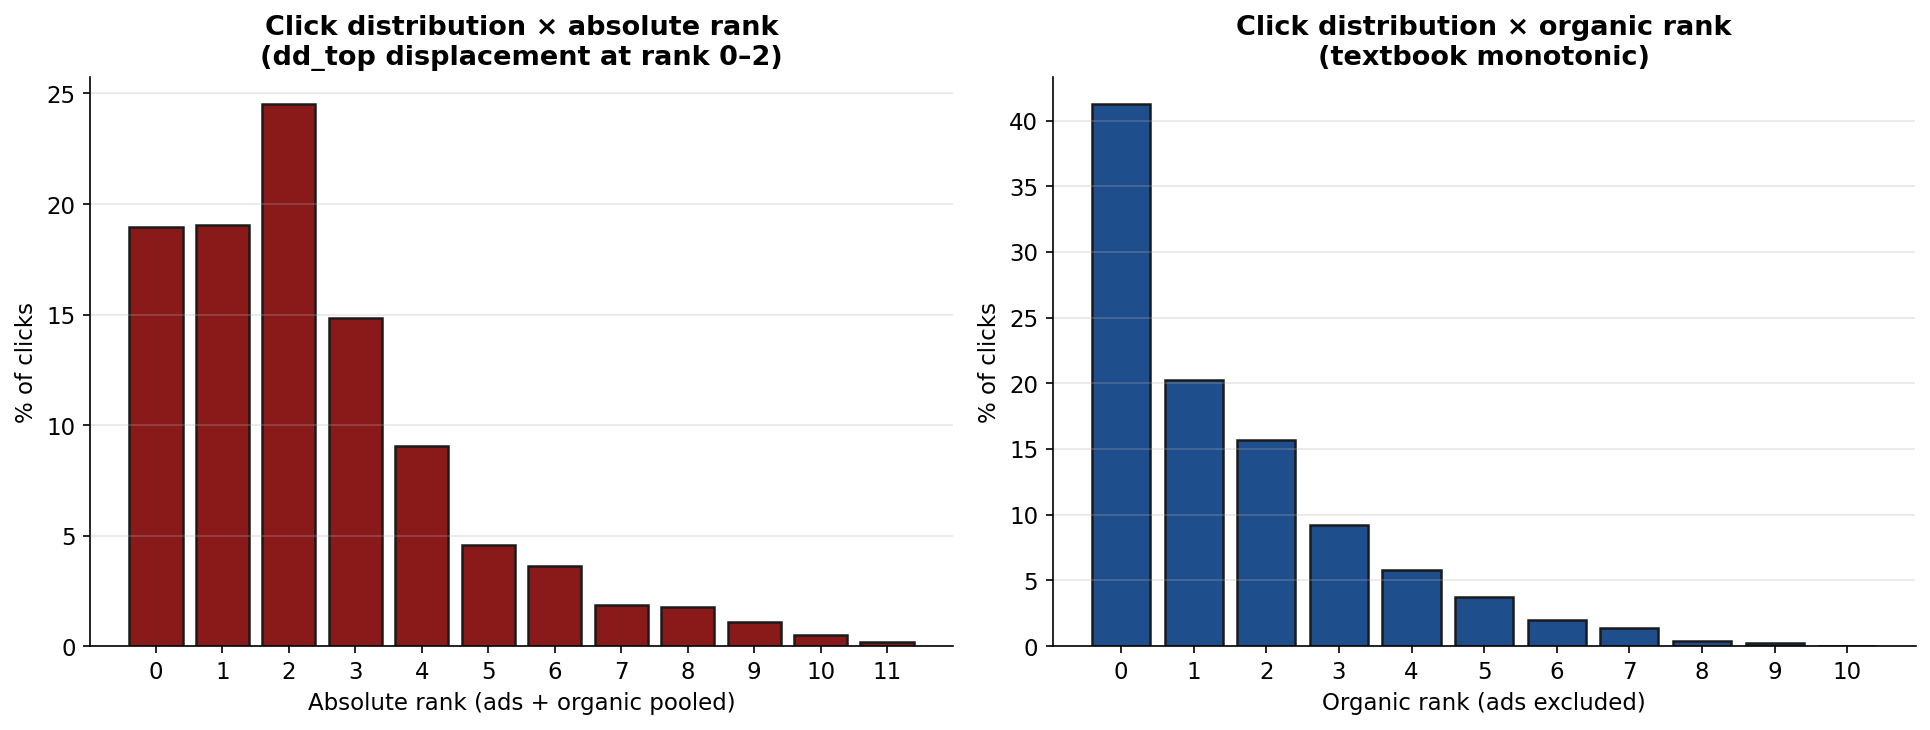

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

abs_ranks = [int(r['abs_rank']) for r in clicks_abs[:12]]
abs_pcts = [float(r['pct']) for r in clicks_abs[:12]]
axes[0].bar(abs_ranks, abs_pcts, color='#8a1a1a', edgecolor='#1a1a1a', linewidth=1.2)
axes[0].set_title('Click distribution × absolute rank\n(dd_top displacement at rank 0–2)', fontweight='semibold')
axes[0].set_xlabel('Absolute rank (ads + organic pooled)')
axes[0].set_ylabel('% of clicks')
axes[0].set_xticks(range(max(abs_ranks) + 1))
axes[0].grid(True, axis='y', alpha=0.3)

org_ranks = [int(r['org_rank']) for r in clicks_org[:12]]
org_pcts = [float(r['pct']) for r in clicks_org[:12]]
axes[1].bar(org_ranks, org_pcts, color='#1f4e8c', edgecolor='#1a1a1a', linewidth=1.2)
axes[1].set_title('Click distribution × organic rank\n(textbook monotonic)', fontweight='semibold')
axes[1].set_xlabel('Organic rank (ads excluded)')
axes[1].set_ylabel('% of clicks')
axes[1].set_xticks(range(max(org_ranks) + 1))
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Validation cohorts for position-based analyses

In [7]:
print('Validation cohorts:')
for name, info in cohort.items():
    n = info['n_trials']; pct = info['pct_of_corpus']
    parts = info['unique_participants']
    print(f'  {name:26s}  n = {n:>5}  ({pct:5.2f}%)  participants = {parts}')

print()
print('Definitions:')
print('  plain_top      - no dd_top ad at absolute rank 0 (any native_ad allowed)')
print('  no_any_ad      - zero ad rects in the result column at all')
print('  clean_for_ctr  - plain_top AND organic rank count in {9, 10, 11}')
print('                   recommended cohort for ETTAC/CIKM CTR-by-rank figures')

Validation cohorts:
  textbook_10org              n =    16  ( 0.58%)  participants = 11
  plain_top                   n =   776  (27.95%)  participants = 47
  no_ddtop                    n =  1194  (43.01%)  participants = 47
  no_any_ad                   n =    53  ( 1.91%)  participants = 33
  canonical_10org_leq2ddtop   n =    35  ( 1.26%)  participants = 22
  clean_for_ctr               n =   555  (19.99%)  participants = 47

Definitions:
  plain_top      - no dd_top ad at absolute rank 0 (any native_ad allowed)
  no_any_ad      - zero ad rects in the result column at all
  clean_for_ctr  - plain_top AND organic rank count in {9, 10, 11}
                   recommended cohort for ETTAC/CIKM CTR-by-rank figures


## 5. Ad exposure is query-intrinsic, not participant/block

In [8]:
top_brands = read_csv(SURVEY_DIR / 'top_brands_ddtop.csv')
print('Top brands by dd_top rate per trial:')
print(f'{"brand":<15}  {"n":>5}  {"dd_top/trial":>14}  {"native/trial":>14}')
for r in top_brands[:15]:
    print(f'{r["brand"]:<15}  {int(r["n_trials"]):>5}  {float(r["mean_ddtop"]):>14.3f}  {float(r["mean_native"]):>14.3f}')

Top brands by dd_top rate per trial:
brand                n    dd_top/trial    native/trial
delphi              40           0.930           3.580
blomus              12           0.920           3.170
nixon               12           0.920           2.000
gates               62           0.890           3.060
alessi              15           0.800           3.330
monroe              46           0.760           4.000
kyb                 12           0.750           4.670
solaray             12           0.750           4.000
avon                24           0.710           3.330
airtex              21           0.670           3.760
serengeti           20           0.650           3.150
bosch               80           0.640           4.640
casio               10           0.600           3.000
hp                  10           0.600           3.800
denso              113           0.580           4.920


## 6. Takeaways for paper writers

1. **Do not call AdSERP a "10-result SERP dataset."** Only 0.6% of trials match.
   Use "47 participants, 2,776 commercial search trials, Gazepoint GP3 HD at
   150 Hz" and add "modal 12 h3 slots per SERP with heavy ad interleaving" if
   rank structure matters.

2. **Any position-based claim must specify absolute vs organic rank.**
   NB23:K1 (absolute rank, ρ = −0.973) and NB23:K18 (organic rank, ρ = −1.000)
   differ materially. The rank-0→1→2 non-monotonicity in K1 is `dd_top`
   displacement, not cognition.

3. **The `clean_for_ctr` cohort (555 trials, ~20%)** is the recommended
   figure cohort for CTR-by-rank plots. Plain-top and organic count ∈ {9,10,11}.

4. **Ad exposure is query/brand-intrinsic.** Don't tell confound stories at
   the participant or block level — they're flat. Do tell them at the brand
   or category level (automotive parts = high ad density).

5. **The Survey phase is gist formation + top-ad attention capture** — not
   deliberate ad-mapping. See [`docs/survey-phase-vs-ads.md`](../docs/survey-phase-vs-ads.md).